# Amazon Sales Analysis

This notebook walks through the Amazon sales dataset and shows the main metrics, trends, and visualizations used to answer the business questions.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
DATA_PATH = Path('amazon.xlsx')
df = pd.read_excel(DATA_PATH, parse_dates=['OrderDate'])
df['Sales'] = df['TotalAmount']
CATEGORY_MARGIN = {
    'Books': 0.12,
    'Home & Kitchen': 0.18,
    'Clothing': 0.22,
    'Toys & Games': 0.20,
    'Sports & Outdoors': 0.18,
    'Electronics': 0.16,
}
df['RevenueExTax'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])
df['ProfitMargin'] = df['Category'].map(CATEGORY_MARGIN).fillna(0.18)
df['Profit'] = (df['RevenueExTax'] * df['ProfitMargin']) - df['Tax'] - df['ShippingCost']
df['OrderMonth'] = df['OrderDate'].dt.to_period('M').dt.to_timestamp()
df['SubCategory'] = df['Brand']
df['IsCompleted'] = df['OrderStatus'].isin(['Delivered', 'Shipped'])

## Q1: Load the dataset and display the first five records

In [4]:
df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,State,Country,SellerID,Sales,RevenueExTax,ProfitMargin,Profit,OrderMonth,SubCategory,IsCompleted
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,DC,India,SELL01967,319.86,319.7700,0.12,38.28240,2023-01-01,BrightLux,True
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,TX,United States,SELL01298,259.64,238.8015,0.18,22.14427,2023-12-01,UrbanStyle,True
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,TX,United States,SELL00908,108.06,94.5810,0.22,7.32782,2022-05-01,UrbanStyle,True
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,NC,India,SELL01164,159.66,142.7150,0.18,8.73870,2023-07-01,Zenith,True
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,TX,Canada,SELL01411,821.36,773.4600,0.22,122.26120,2023-02-01,KiddoFun,False


## Q2: Dataset overview

In [7]:
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('Data types:')
print(df.dtypes)
print('Numerical summary:')
df.describe(include='number')

Shape: (100000, 27)
Columns: ['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID', 'ProductName', 'Category', 'Brand', 'Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount', 'PaymentMethod', 'OrderStatus', 'City', 'State', 'Country', 'SellerID', 'Sales', 'RevenueExTax', 'ProfitMargin', 'Profit', 'OrderMonth', 'SubCategory', 'IsCompleted']
Data types:
OrderID                  object
OrderDate        datetime64[ns]
CustomerID               object
CustomerName             object
ProductID                object
ProductName              object
Category                 object
Brand                    object
Quantity                  int64
UnitPrice               float64
Discount                float64
Tax                     float64
ShippingCost            float64
TotalAmount             float64
PaymentMethod            object
OrderStatus              object
City                     object
State                    object
Country                  object
Selle

,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,Sales,RevenueExTax,ProfitMargin,Profit
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,3.001400,302.905748,0.074226,68.468902,7.406660,918.256479,918.256479,842.380938,0.176462,72.890986
std,1.413548,171.840797,0.082583,74.131180,4.324057,724.508332,724.508332,668.187115,0.031419,88.020603
min,1.000000,5.000000,0.000000,0.000000,0.000000,4.270000,4.270000,3.899000,0.120000,-187.750000
25%,2.000000,154.190000,0.000000,15.920000,3.680000,340.890000,340.890000,308.971250,0.160000,10.246687
50%,3.000000,303.070000,0.050000,45.250000,7.300000,714.315000,714.315000,655.882000,0.180000,45.503000
75%,4.000000,451.500000,0.100000,96.060000,11.150000,1349.765000,1349.765000,1241.190250,0.200000,110.186430
max,5.000000,599.990000,0.300000,538.460000,15.000000,3534.980000,3534.980000,2999.950000,0.220000,653.372000


## Q3: KPI Analysis

In [8]:
completed = df[df['IsCompleted']]
kpis = {
    'Total Sales': completed['Sales'].sum(),
    'Total Profit': completed['Profit'].sum(),
    'Total Orders': completed['OrderID'].nunique(),
    'Average Sales': completed['Sales'].mean(),
    'Average Profit': completed['Profit'].mean(),
    'Maximum Sales': completed['Sales'].max(),
    'Minimum Sales': completed['Sales'].min(),
}
kpis

{'Total Sales': 82456306.09,
 'Total Profit': 6544153.96355,
 'Total Orders': 89820,
 'Average Sales': 918.0172132041862,
 'Average Profit': 72.85853889501225,
 'Maximum Sales': 3534.98,
 'Minimum Sales': 4.27}

## Q4: Total sales by state

In [9]:
sales_state = completed.groupby('State', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
sales_state

,State,Sales
11,TX,20635847.22
1,CA,16351664.74
7,NC,4298547.68
12,WA,4189455.72
10,PA,4166124.62
5,IL,4161551.37
2,CO,4153686.61
9,OH,4137317.84
4,FL,4117885.37
8,NY,4114209.97


## Q5: Total sales by category

In [10]:
sales_category = completed.groupby('Category', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
sales_category

,Category,Sales
2,Electronics,14014488.97
4,Sports & Outdoors,13780079.42
0,Books,13754680.67
1,Clothing,13730018.54
5,Toys & Games,13601805.72
3,Home & Kitchen,13575232.77


## Q7: Total sales by sub-category proxy (Brand)

Because the dataset does not include a dedicated `Sub-Category` field, this analysis uses `Brand` as a stand-in.

In [11]:
sales_subcategory = completed.groupby('SubCategory', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False)
sales_subcategory.head(20)

,SubCategory,Sales
5,KiddoFun,8388602.45
2,CoreTech,8369188.87
7,ReadMore,8362463.31
8,UrbanStyle,8354911.21
9,Zenith,8262782.62
0,Apex,8212005.22
3,FitLife,8154914.41
6,NexPro,8126522.51
1,BrightLux,8115777.23
4,HomeEase,8109138.26


## Q9: Top 5 customers by total sales

In [12]:
top_customers = completed.groupby('CustomerName', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False).head(5)
top_customers

,CustomerName,Sales
92,Pooja Kapoor,479432.76
10,Aditya Gupta,474457.28
51,Kabir Joshi,471347.67
178,Vihaan Singh,468494.69
73,Mohit Kumar,465049.04


## Q10: Total quantity sold by product

In [13]:
quantity_by_product = completed.groupby('ProductName', as_index=False)['Quantity'].sum().sort_values('Quantity', ascending=False)
quantity_by_product.head(20)

,ProductName,Quantity
22,LED Desk Lamp,5697
44,Water Bottle,5659
35,Router,5625
5,Board Game,5616
26,Microphone,5603
25,Memory Card 128GB,5569
47,Wireless Charger,5530
13,Electric Kettle,5527
24,Mechanical Keyboard,5522
21,Kids Toy Car,5518


## Q11: Orders by payment mode

In [14]:
payment_counts = completed['PaymentMethod'].value_counts().rename_axis('PaymentMethod').reset_index(name='OrderCount')
payment_counts

,PaymentMethod,OrderCount
0,Credit Card,31409
1,Debit Card,17990
2,UPI,13583
3,Amazon Pay,13499
4,Net Banking,8906
5,Cash on Delivery,4433


## Q12: Monthly sales trend

In [15]:
monthly_sales = completed.groupby('OrderMonth', as_index=False)['Sales'].sum().sort_values('OrderMonth')
monthly_sales

,OrderMonth,Sales
0,2020-01-01,1457144.57
1,2020-02-01,1229077.58
2,2020-03-01,1406480.34
3,2020-04-01,1423935.70
4,2020-05-01,1395638.01
5,2020-06-01,1374382.07
6,2020-07-01,1393676.51
7,2020-08-01,1460692.09
8,2020-09-01,1400759.16
9,2020-10-01,1384196.08


## Q13: Sales by state and category

In [16]:
state_category = completed.groupby(['State', 'Category'], as_index=False)['Sales'].sum().sort_values(['State', 'Category'])
state_category.head(30)

,State,Category,Sales
0,AZ,Books,716000.20
1,AZ,Clothing,615117.74
2,AZ,Electronics,681737.62
3,AZ,Home & Kitchen,652052.55
4,AZ,Sports & Outdoors,629120.45
5,AZ,Toys & Games,753994.24
6,CA,Books,2727297.02
7,CA,Clothing,2714102.83
8,CA,Electronics,2761502.95
9,CA,Home & Kitchen,2648508.59


## Visualizations
The charts below show the key insights from the analysis.

/tmp/ipykernel_11404/599471491.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_state, x='Sales', y='State', palette='viridis')


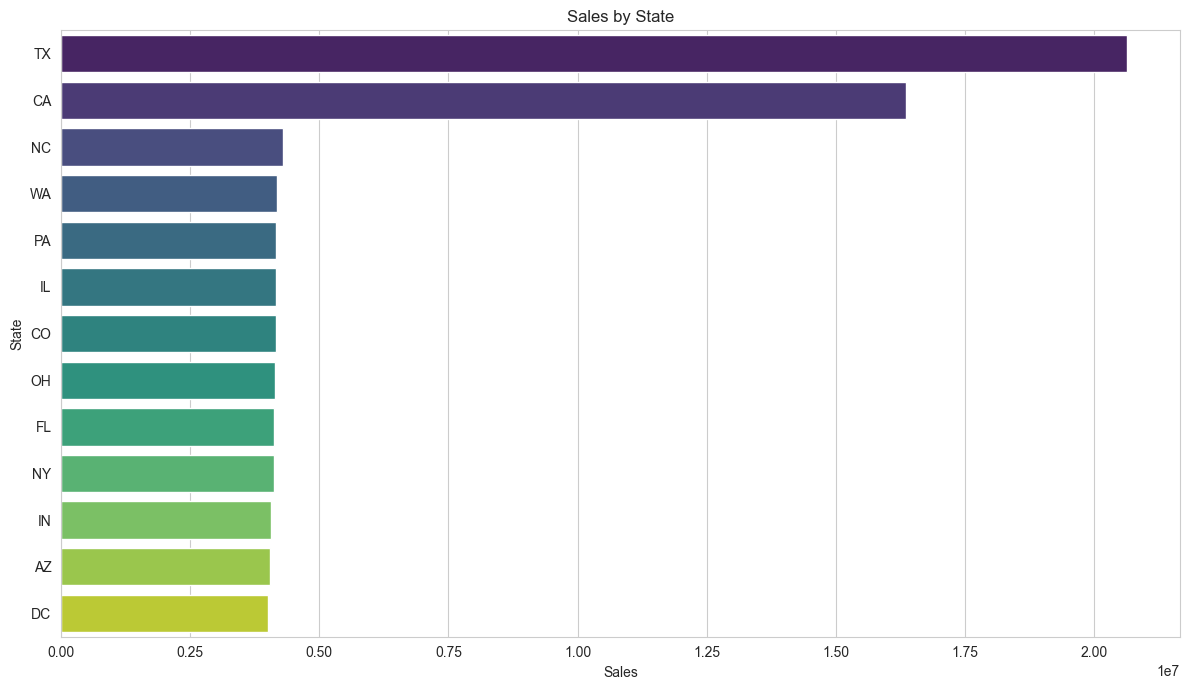

In [17]:
plt.figure(figsize=(12, 7))
sns.barplot(data=sales_state, x='Sales', y='State', palette='viridis')
plt.title('Sales by State')
plt.tight_layout()
plt.show()

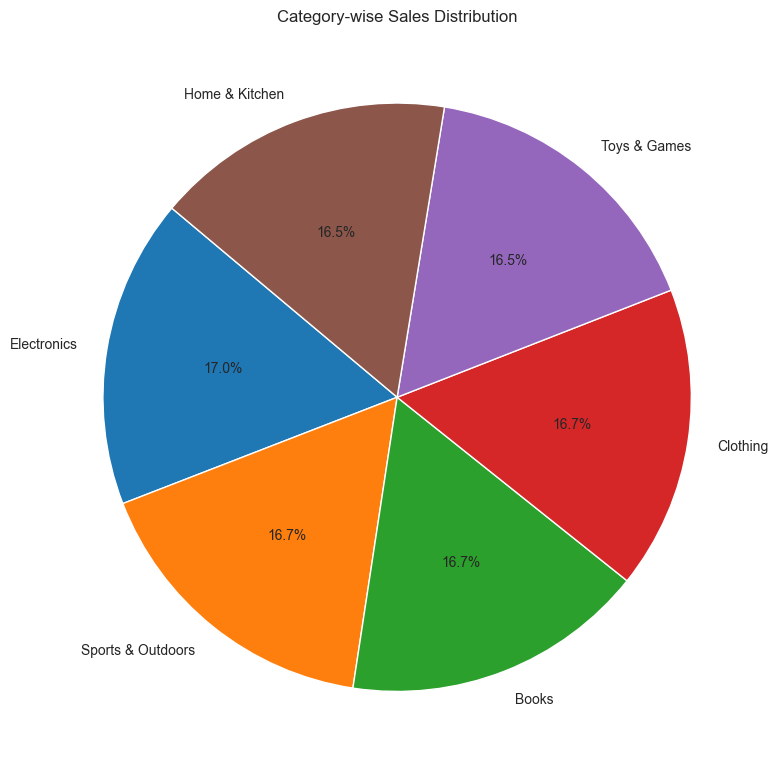

In [18]:
plt.figure(figsize=(8, 8))
plt.pie(sales_category['Sales'], labels=sales_category['Category'], autopct='%.1f%%', startangle=140)
plt.title('Category-wise Sales Distribution')
plt.tight_layout()
plt.show()

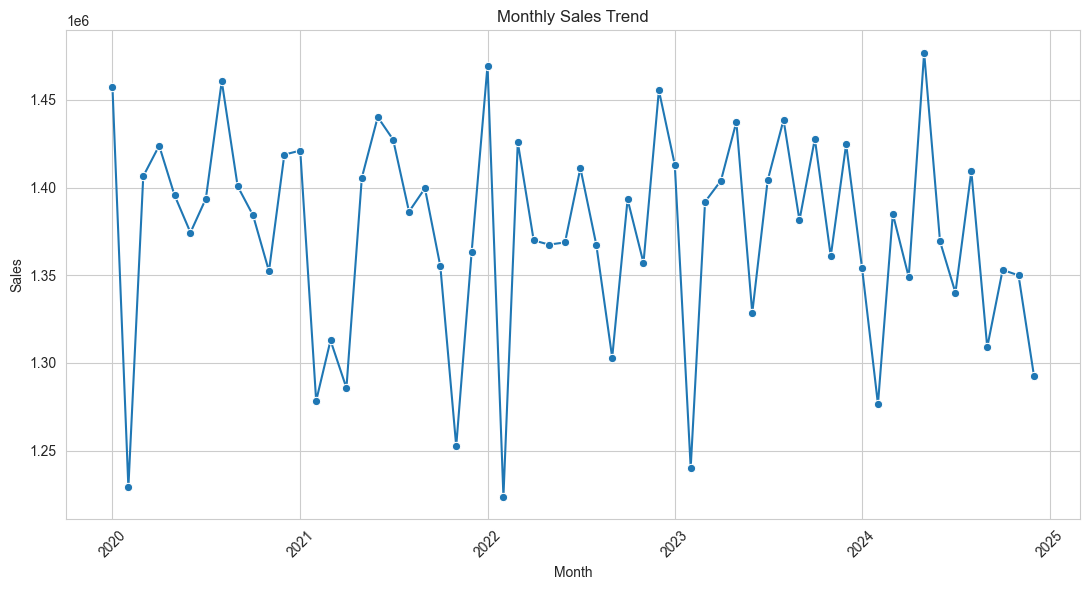

In [19]:
plt.figure(figsize=(11, 6))
sns.lineplot(data=monthly_sales, x='OrderMonth', y='Sales', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_11404/1808708729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, x='Sales', y='ProductName', palette='magma')


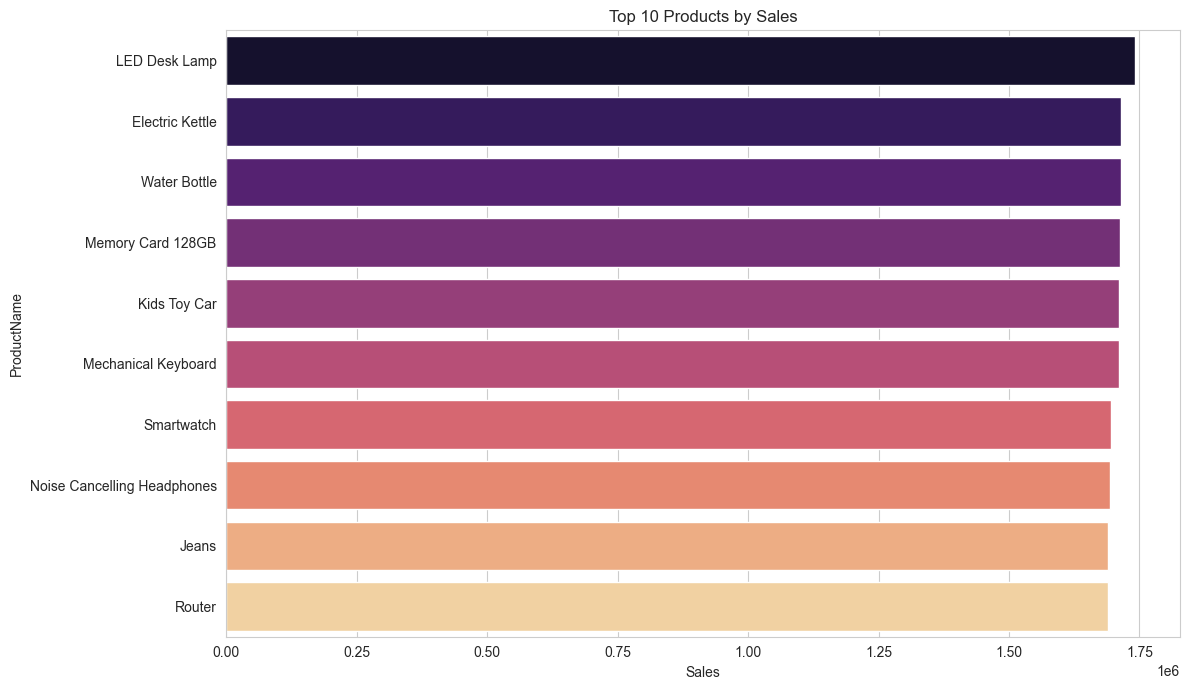

In [20]:
top_products = completed.groupby('ProductName', as_index=False)['Sales'].sum().sort_values('Sales', ascending=False).head(10)
plt.figure(figsize=(12, 7))
sns.barplot(data=top_products, x='Sales', y='ProductName', palette='magma')
plt.title('Top 10 Products by Sales')
plt.tight_layout()
plt.show()

## Business Recommendations

- Focus support on the states that are already doing well, and add targeted campaigns in the areas that need more traffic.
- Keep backing top categories, while watching the cost and profit picture for categories that sell a lot but earn less margin.
- Highlight the payment options customers use most, and plan promotions around the best sales months.